In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns

In [2]:
# Load the parquet file
df = pd.read_parquet("acs_cleaned.parquet")

# **Sanity Checks**
---

In [3]:
df.shape

(15715097, 14)

In [4]:
df.head()

,Year,Individuals Represented,Sex,Age,Education Level (Detailed),Major,Weeks Worked,Hours Worked,Income (Nominal),Demographic,Education Group,State,Income (2024 Dollars),Log Income
0,1980,20,Male,50,112,NaN,52,38,25005,White,Masters or Doctorate,Alaska,95195.007812,11.463683
1,1980,20,Female,58,60,NaN,48,40,18005,White,HS or Less,Alaska,68545.734375,11.135257
2,1980,20,Male,59,70,NaN,50,50,3005,White,Some College,Alaska,11440.151367,9.344885
3,1980,20,Female,47,60,NaN,48,40,27605,White,HS or Less,Alaska,105093.304688,11.562604
4,1980,20,Female,55,80,NaN,52,40,16005,White,Some College,Alaska,60931.656250,11.017509


In [5]:
df.tail()

,Year,Individuals Represented,Sex,Age,Education Level (Detailed),Major,Weeks Worked,Hours Worked,Income (Nominal),Demographic,Education Group,State,Income (2024 Dollars),Log Income
15715092,2024,39,Male,52,64,NaN,52,84,80000,Hispanic,Some College,Wyoming,80000.0,11.289782
15715093,2024,59,Female,45,64,NaN,52,40,27200,Hispanic,Some College,Wyoming,27200.0,10.210972
15715094,2024,51,Female,59,114,Medical and Health Sciences,52,36,46000,White,Masters or Doctorate,Wyoming,46000.0,10.736397
15715095,2024,81,Male,60,114,Education Administration and Teaching,52,40,132000,White,Masters or Doctorate,Wyoming,132000.0,11.790557
15715096,2024,104,Female,56,71,NaN,52,48,32000,White,Some College,Wyoming,32000.0,10.373491


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15715097 entries, 0 to 15715096
Data columns (total 14 columns):
 #   Column                      Dtype   
---  ------                      -----   
 0   Year                        int16   
 1   Individuals Represented     int32   
 2   Sex                         category
 3   Age                         int8    
 4   Education Level (Detailed)  int16   
 5   Major                       category
 6   Weeks Worked                int8    
 7   Hours Worked                int8    
 8   Income (Nominal)            int32   
 9   Demographic                 category
 10  Education Group             category
 11  State                       category
 12  Income (2024 Dollars)       float32 
 13  Log Income                  float32 
dtypes: category(5), float32(2), int16(2), int32(2), int8(3)
memory usage: 419.6 MB


In [7]:
df.describe()

,Year,Individuals Represented,Age,Education Level (Detailed),Weeks Worked,Hours Worked,Income (Nominal),Income (2024 Dollars),Log Income
count,1.571510e+07,1.571510e+07,1.571510e+07,1.571510e+07,1.571510e+07,1.571510e+07,1.571510e+07,1.571510e+07,1.571510e+07
mean,2.003309e+03,9.006376e+01,4.256599e+01,7.787560e+01,5.122579e+01,4.381836e+01,5.088154e+04,7.886309e+04,1.102279e+01
std,1.588823e+01,1.256398e+02,1.085044e+01,2.430702e+01,2.369377e+00,8.075093e+00,6.057432e+04,7.229598e+04,8.086576e-01
min,1.980000e+03,0.000000e+00,2.500000e+01,2.000000e+00,4.000000e+01,3.500000e+01,1.000000e+00,2.400153e+00,8.755325e-01
25%,1.990000e+03,2.000000e+01,3.300000e+01,6.200000e+01,5.200000e+01,4.000000e+01,2.000000e+04,4.051476e+04,1.060942e+01
50%,2.005000e+03,5.400000e+01,4.200000e+01,7.100000e+01,5.200000e+01,4.000000e+01,3.500000e+04,6.108951e+04,1.102010e+01
75%,2.020000e+03,1.070000e+02,5.100000e+01,1.010000e+02,5.200000e+01,4.500000e+01,6.000000e+04,9.210841e+04,1.143072e+01
max,2.024000e+03,4.492000e+03,6.400000e+01,1.160000e+02,5.200000e+01,9.900000e+01,9.070000e+05,1.010329e+06,1.382579e+01


# **Data Quality Checks**
---

In [8]:
df.isna().sum().sort_values(ascending=False)

Major                         13159731
Year                                 0
Individuals Represented              0
Sex                                  0
Age                                  0
Education Level (Detailed)           0
Weeks Worked                         0
Hours Worked                         0
Income (Nominal)                     0
Demographic                          0
Education Group                      0
State                                0
Income (2024 Dollars)                0
Log Income                           0
dtype: int64

In [9]:
(df.isna().mean() * 100).sort_values(ascending=False)

Major                         83.739419
Year                           0.000000
Individuals Represented        0.000000
Sex                            0.000000
Age                            0.000000
Education Level (Detailed)     0.000000
Weeks Worked                   0.000000
Hours Worked                   0.000000
Income (Nominal)               0.000000
Demographic                    0.000000
Education Group                0.000000
State                          0.000000
Income (2024 Dollars)          0.000000
Log Income                     0.000000
dtype: float64

In [10]:
for col in df.select_dtypes("category"):
    print(col)
    print(df[col].value_counts())
    print()

Sex
Sex
Male      9194479
Female    6520618
Name: count, dtype: int64

Major
Major
Business                                 543194
Engineering                              237464
Education Administration and Teaching    219139
Medical and Health Sciences              195139
Social Sciences                          185810
Biology and Life Sciences                136391
Psychology                               121771
Computer and Information Sciences        115493
Communications                           109098
Fine Arts                                 94693
Physical Sciences                         73957
English/Literature                        68934
Criminal Justice                          54649
History                                   49427
Mathematics and Statistics                35804
Public Affairs and Social Work            34412
Parks/Recreation/Leisure                  33035
Agriculture                               28941
Liberal Arts and Humanities               28465
Inter

# **Weighted Summary Statistics**
---

In [11]:
def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

weighted_mean(df["Income (2024 Dollars)"], df["Individuals Represented"])

np.float64(80982.4807338109)

# **Income Distribution**
---

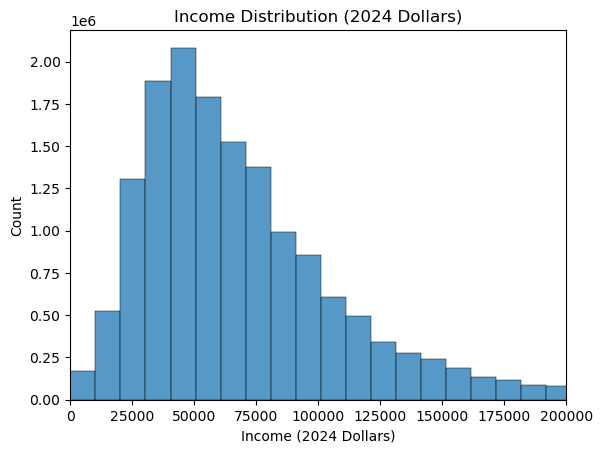

In [12]:
sns.histplot(
    df["Income (2024 Dollars)"],
    bins=100
)

plt.xlim(0,200000)
plt.title("Income Distribution (2024 Dollars)")
plt.show()

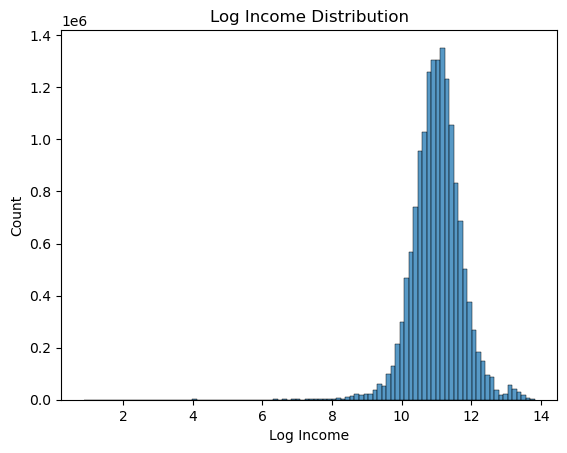

In [13]:
sns.histplot(df["Log Income"], bins=100)
plt.title("Log Income Distribution")
plt.show()

# **Income Over Time**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/451421365.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


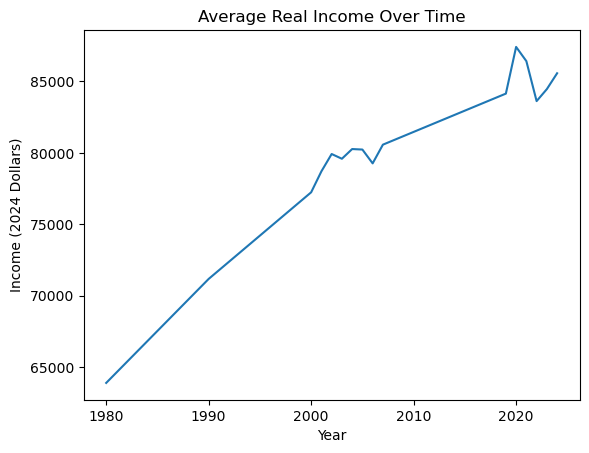

In [14]:
income_year = (
    df.groupby("Year")
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
)

income_year.plot()
plt.title("Average Real Income Over Time")
plt.ylabel("Income (2024 Dollars)")
plt.show()

# **Income By Education**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/2010538518.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Education Group")
/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/2010538518.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


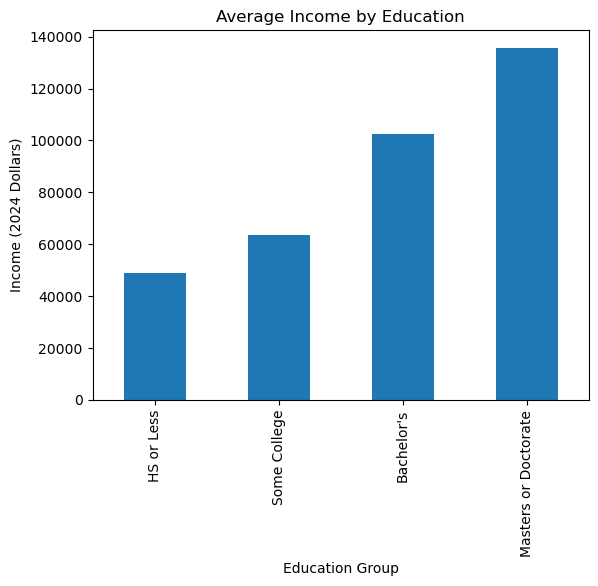

In [15]:
income_edu = (
    df.groupby("Education Group")
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
      .sort_values()
)

income_edu.plot(kind="bar")
plt.title("Average Income by Education")
plt.ylabel("Income (2024 Dollars)")
plt.show()

# **Education Wage Premium**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/3296880880.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Year","Education Group"])
/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/3296880880.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


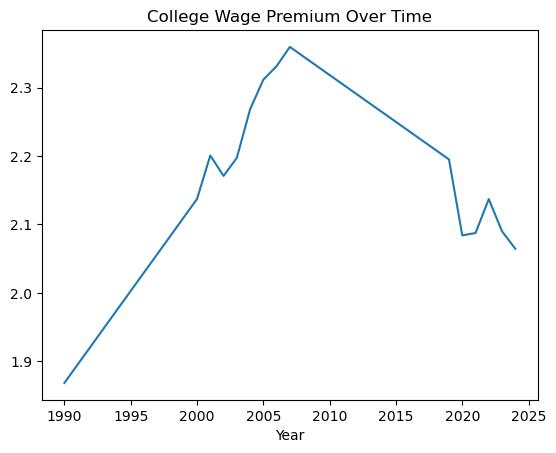

In [16]:
premium = (
    df.groupby(["Year","Education Group"])
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
      .unstack()
)

premium["College Premium"] = (
    premium["Bachelor's"] / premium["HS or Less"]
)

premium["College Premium"].plot()
plt.title("College Wage Premium Over Time")
plt.show()

# **Income By Gender**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/1312276284.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Year","Sex"])
/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/1312276284.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


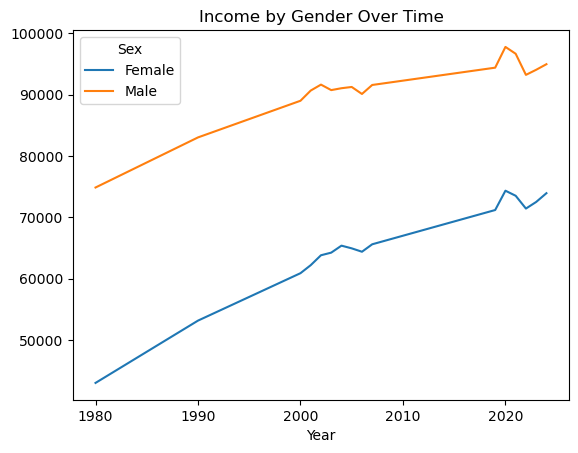

In [17]:
income_gender = (
    df.groupby(["Year","Sex"])
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
      .unstack()
)

income_gender.plot()
plt.title("Income by Gender Over Time")
plt.show()

# **Education + Gender**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/3654788838.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Year","Sex","Education Group"])
/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/3654788838.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


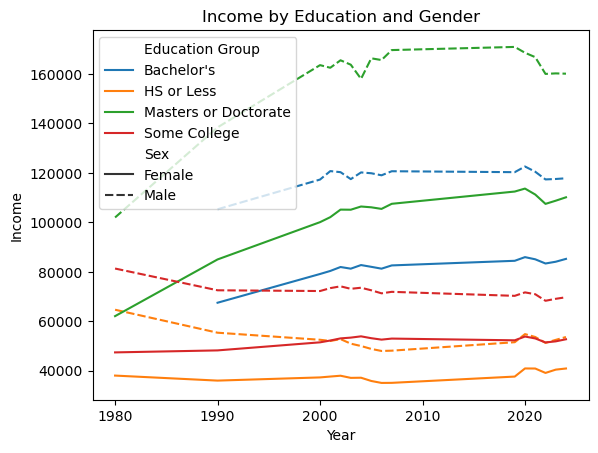

In [18]:
edu_gender = (
    df.groupby(["Year","Sex","Education Group"])
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
      .reset_index(name="Income")
)

sns.lineplot(
    data=edu_gender,
    x="Year",
    y="Income",
    hue="Education Group",
    style="Sex"
)

plt.title("Income by Education and Gender")
plt.show()

# **Income By Demographic**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/2111289877.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Year","Demographic"])
/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/2111289877.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


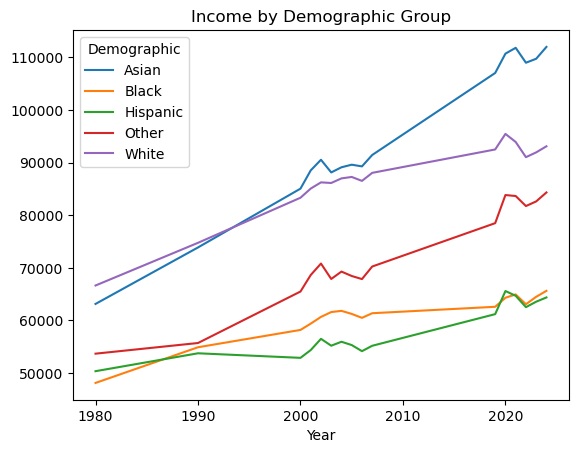

In [19]:
income_demo = (
    df.groupby(["Year","Demographic"])
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
      .unstack()
)

income_demo.plot()
plt.title("Income by Demographic Group")
plt.show()

# **Age Profile of Income**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/1973432296.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


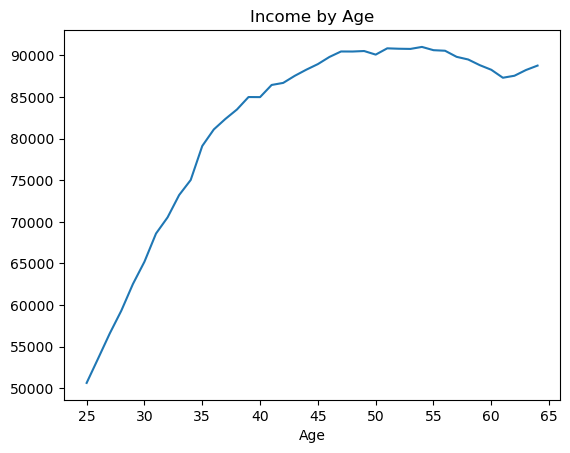

In [20]:
age_income = (
    df.groupby("Age")
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
)

age_income.plot()
plt.title("Income by Age")
plt.show()

# **Hours vs Income**
---

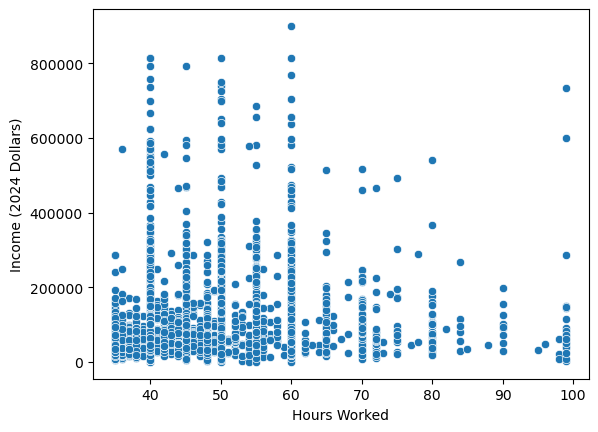

In [21]:
sns.scatterplot(
    data=df.sample(10000),
    x="Hours Worked",
    y="Income (2024 Dollars)"
)
plt.show()

# **State Level Income**
---

In [22]:
state_income = (
    df.groupby("State")
      .apply(lambda x: weighted_mean(
          x["Income (2024 Dollars)"],
          x["Individuals Represented"]
      ))
      .sort_values(ascending=False)
)

state_income.head(10)

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/4161555676.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("State")
/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/4161555676.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: weighted_mean(


State
District of Columbia    114904.467787
Connecticut             101963.731700
New Jersey              100060.489826
Massachusetts            99015.171353
New York                 92457.671411
Maryland                 92357.354982
California               91866.654211
Washington               91621.173790
Virginia                 87358.600807
Colorado                 86457.919074
dtype: float64

# **Correlation Matrix**
---

In [23]:
df.corr(numeric_only=True)

,Year,Individuals Represented,Age,Education Level (Detailed),Weeks Worked,Hours Worked,Income (Nominal),Income (2024 Dollars),Log Income
Year,1.000000,0.292828,0.146919,0.234393,0.130746,0.016054,0.408415,0.126211,0.118270
Individuals Represented,0.292828,1.000000,-0.007900,0.039870,0.039074,0.008894,0.088882,0.020639,0.018868
Age,0.146919,-0.007900,1.000000,-0.055910,0.048833,0.006410,0.148848,0.130324,0.129243
Education Level (Detailed),0.234393,0.039870,-0.055910,1.000000,0.007566,0.077436,0.349615,0.341477,0.396474
Weeks Worked,0.130746,0.039074,0.048833,0.007566,1.000000,0.035857,0.098384,0.081956,0.124587
Hours Worked,0.016054,0.008894,0.006410,0.077436,0.035857,1.000000,0.170527,0.205770,0.195990
Income (Nominal),0.408415,0.088882,0.148848,0.349615,0.098384,0.170527,1.000000,0.917384,0.703701
Income (2024 Dollars),0.126211,0.020639,0.130324,0.341477,0.081956,0.205770,0.917384,1.000000,0.803850
Log Income,0.118270,0.018868,0.129243,0.396474,0.124587,0.195990,0.703701,0.803850,1.000000


<Axes: >

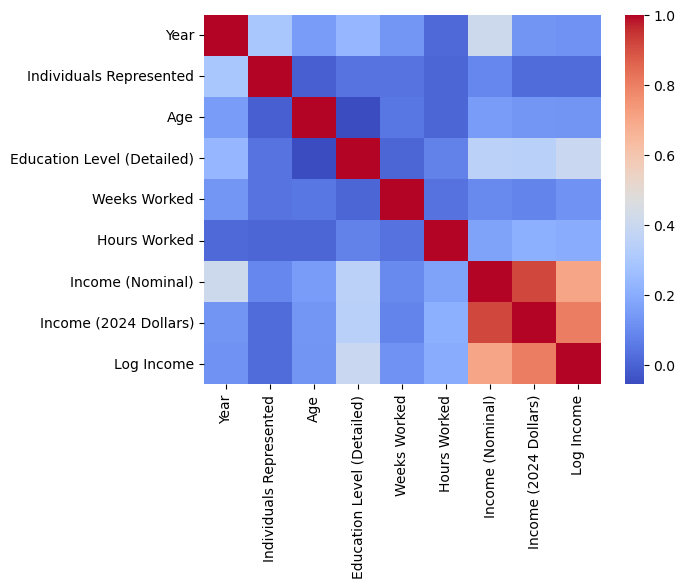

In [24]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

# **Distribution of Education**
---

/var/folders/ct/wjpkwtvn40733jk863tfylzm0000gn/T/ipykernel_54209/3107782143.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Education Group")["Individuals Represented"]


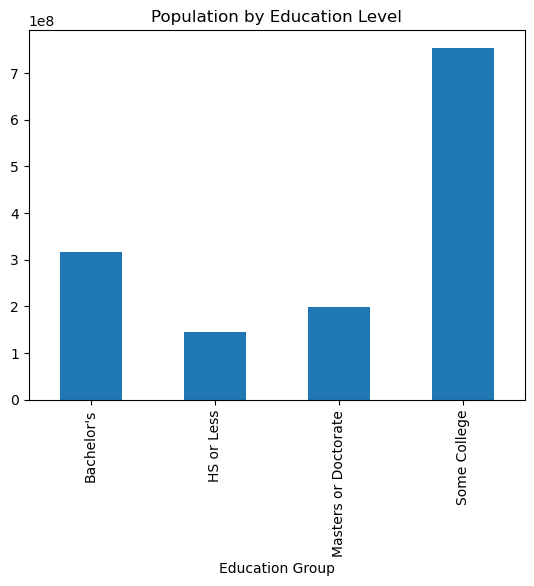

In [25]:
edu_dist = (
    df.groupby("Education Group")["Individuals Represented"]
      .sum()
)

edu_dist.plot(kind="bar")
plt.title("Population by Education Level")
plt.show()